In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 500
klienci = ["Anna Kowalska", "  Jan Nowak", "Anna Kowalska", "PIOTR WIŚNIEWSKI",
           "katarzyna lewandowska", "Tomasz Zieliński ", "Marta Wójcik",
           "anna kowalska ", "Krzysztof Kamiński", " Magdalena Dąbrowska"]

produkty = ["Laptop", "Mysz", "Klawiatura", "Monitor", "laptop", "MYSZ",
            "Słuchawki", "Pendrive", "monitor", "Webcam"]

kategorie = ["Elektronika", "elektronika", "ELEKTRONIKA", "Akcesoria",
             "akcesoria", "Akcesoria "]

miasta = ["Warszawa", "Kraków", "warszawa", "Gdańsk", "WROCŁAW",
          "Poznań", "Łódź ", " Warszawa", "kraków"]

start_date = datetime(2025, 1, 1)

daty_iso = [
    (start_date + timedelta(days=int(d))).strftime("%Y-%m-%d")
    for d in np.random.randint(0, 300, n // 2)
]

daty_pl = [
    (start_date + timedelta(days=int(d))).strftime("%d.%m.%Y")
    for d in np.random.randint(0, 300, n // 2)
]

daty = daty_iso + daty_pl
np.random.shuffle(daty)

df = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "klient": np.random.choice(klienci, n),
    "produkt": np.random.choice(produkty, n),
    "kategoria": np.random.choice(kategorie, n),
    "miasto": np.random.choice(miasta, n),
    "ilosc": np.random.choice(
        [1, 2, 3, 5, -1, 0],
        n,
        p=[0.5, 0.2, 0.15, 0.1, 0.025, 0.025]
    ),
    "cena_jednostkowa": np.random.choice(
        ["199.99", "299,99", "1 499.00", "89.50", "2999", "399.00 zł", None, "abc"],
        n
    ),
    "data_zamowienia": daty,
    "email": np.random.choice(
        ["anna@gmail.com", "JAN@WP.PL", "piotr.w@onet", "marta@gmail.com",
         "tomasz@interia.pl", None, "krzysztof.k@gmail.com", "brak"],
        n
    )
})

for col in ["miasto", "kategoria", "data_zamowienia"]:
    df.loc[df.sample(frac=0.05, random_state=1).index, col] = np.nan

df = pd.concat([df, df.sample(20, random_state=2)], ignore_index=True)

df.to_csv("zamowienia_messy.csv", index=False)

print(f"Wygenerowano plik 'zamowienia_messy.csv' — {len(df)} wierszy")

Wygenerowano plik 'zamowienia_messy.csv' — 520 wierszy



SHAPE:
(520, 9)

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB
None

DESCRIBE:
           order_id         klient produkt  kategoria    miasto       ilosc  \
count    520.000000            520     520        495       495  520.000000   
unique          NaN              9      10          6         9         NaN   
top             NaN  Anna Kowalska    Mysz  Akcesoria  warszawa         NaN   
freq     

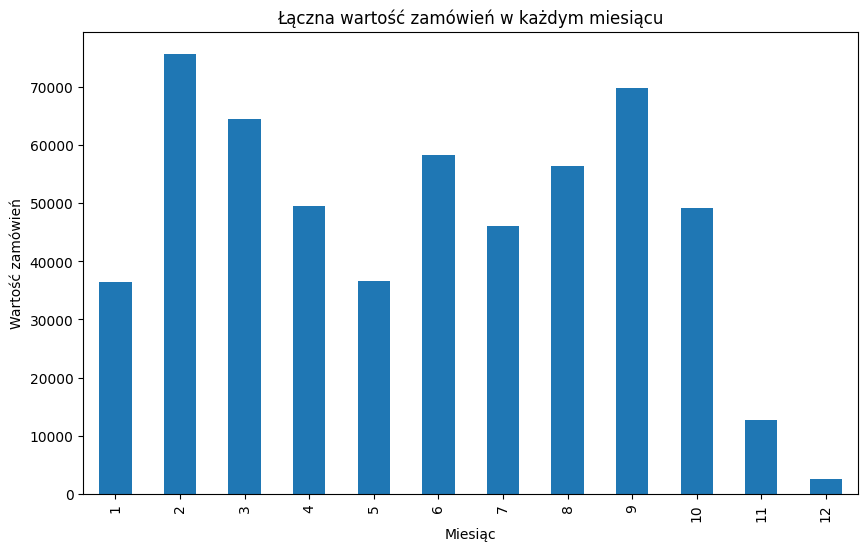


Zapisano plik zamowienia_clean.csv


In [4]:
import matplotlib.pyplot as plt

df = pd.read_csv("zamowienia_messy.csv")

print("\nSHAPE:")
print(df.shape)

print("\nINFO:")
print(df.info())

print("\nDESCRIBE:")
print(df.describe(include="all"))

print("\nNULLS:")
print(df.isnull().sum())

print("\nKLIENCI:")
print(df["klient"].value_counts())

print("\nPRODUKTY:")
print(df["produkt"].value_counts())

print("\nKATEGORIE:")
print(df["kategoria"].value_counts())

print("\nMIASTA:")
print(df["miasto"].value_counts())


# CZYSZCZENIE
# Duplikaty
df = df.drop_duplicates()
# Standaryzacja
df["klient"] = df["klient"].str.strip().str.title()
df["produkt"] = df["produkt"].str.strip().str.title()
df["kategoria"] = (
    df["kategoria"]
    .astype(str)
    .str.strip()
    .str.lower()
)
df["miasto"] = (
    df["miasto"]
    .astype(str)
    .str.strip()
    .str.title()
)
# Daty
df["data_zamowienia"] = pd.to_datetime(
    df["data_zamowienia"],
    errors="coerce",
    format="mixed"
)
# Czyszczenie cen
df["cena_jednostkowa"] = (
    df["cena_jednostkowa"]
    .astype(str)
    .str.replace("zł", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
)
# Konwersja ceny
df["cena_jednostkowa"] = pd.to_numeric(
    df["cena_jednostkowa"],
    errors="coerce"
)
# Obsługa braków
df = df.dropna(subset=["cena_jednostkowa", "data_zamowienia"])
df["miasto"] = df["miasto"].replace("Nan", "unknown")
df["kategoria"] = df["kategoria"].replace("nan", "unknown")
df["email"] = df["email"].fillna("brak_emaila")
# Usunięcie błędnych ilości
df = df[df["ilosc"] > 0]

# TRANSFORMACJE
# Wartość zamówienia
df["wartosc_zamowienia"] = (
    df["ilosc"] * df["cena_jednostkowa"]
)
# Rok / miesiąc / dzień
df["rok"] = df["data_zamowienia"].dt.year
df["miesiac"] = df["data_zamowienia"].dt.month
df["nazwa_dnia"] = df["data_zamowienia"].dt.day_name()
# Walidacja emaila
pattern = r"^[\w\.-]+@[\w\.-]+\.\w+$"
df["email_poprawny"] = df["email"].str.match(
    pattern,
    na=False
)

# ANALIZA
# Łączna wartość zamówień/mies
monthly_sales = (
    df.groupby("miesiac")["wartosc_zamowienia"]
    .sum()
)

print("\nŁĄCZNA WARTOŚĆ ZAMÓWIEŃ W KAŻDYM MIESIĄCU:")
print(monthly_sales)


# Top 5 klientów
top_clients = (
    df.groupby("klient")["wartosc_zamowienia"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTOP 5 KLIENTÓW:")
print(top_clients)


# Średnia wartość zamówienia per kategoria
avg_category = (
    df.groupby("kategoria")["wartosc_zamowienia"]
    .mean()
)

print("\nŚREDNIA WARTOŚĆ ZAMÓWIENIA:")
print(avg_category)

# WIZUALIZACJA
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind="bar")
plt.title("Łączna wartość zamówień w każdym miesiącu")
plt.xlabel("Miesiąc")
plt.ylabel("Wartość zamówień")
plt.show()

# ZAPIS
df.to_csv("zamowienia_clean.csv", index=False)

print("\nZapisano plik zamowienia_clean.csv")

1. Duplikaty danych
2. Braki danych (NaN)
3. Różne formaty dat
4. Niespójna wielkość liter
5. Białe znaki w tekstach
6. Niepoprawne ceny
7. Niepoprawne emaile
8. Ujemne lub zerowe ilości